# Log File Analysis using PySpark
### Big Data Analytics — Mini Project 6

**Author:** Easy Storage  
**Date:** May 2026  
**Tools:** PySpark, Pandas, Matplotlib, Jupyter Notebook (Anaconda)

---

## Project Overview

This project performs comprehensive analysis on Apache web server access logs using **PySpark** to demonstrate big data processing techniques. We go beyond the basic requirements by adding three novelty features:

**Core Tasks (Required):**
1. Load server log data
2. Count number of requests
3. Find most frequent IP
4. Filter error logs

**Novelty Additions (Bonus):**
5. **Time-series traffic analysis** — hourly/daily request patterns with visualization
6. **Anomaly / suspicious IP detection** — security-focused threat hunting
7. **Bot vs Human traffic split** — User-Agent classification

---

## 1. Setup — Import Libraries & Initialize Spark Session

In [1]:
import os
import re
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, regexp_extract, count, desc, when, hour, to_timestamp,
    dayofweek, date_format, sum as _sum, lit, length
)
from pyspark.sql.types import IntegerType

spark = (
    SparkSession.builder
    .appName("LogFileAnalysis")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("Spark Version:", spark.version)
print("Spark Session created successfully!")

Spark Version: 4.1.1
Spark Session created successfully!


## 2. Task 1 — Load Server Log Data

Apache logs follow the **Combined Log Format**:
```
IP - - [timestamp] "METHOD /url HTTP/1.1" status size "referrer" "user-agent"
```

We load the raw log file as a text DataFrame, then parse each field using **regex extraction** — a classic Big Data pattern for semi-structured data.

In [2]:
LOG_PATH = "access.log"
raw_logs = spark.read.text(LOG_PATH)
print(f"Total raw lines loaded: {raw_logs.count():,}")
raw_logs.show(3, truncate=80)

Total raw lines loaded: 5,000
+--------------------------------------------------------------------------------+
|                                                                           value|
+--------------------------------------------------------------------------------+
|192.168.31.207 - - [12/May/2026:00:02:43 +0000] "GET /css/style.css HTTP/1.1"...|
|203.124.45.18 - - [12/May/2026:00:17:13 +0000] "GET /search?q=phone HTTP/1.1"...|
|192.168.48.139 - - [12/May/2026:00:28:58 +0000] "GET /api/users HTTP/1.1" 404...|
+--------------------------------------------------------------------------------+
only showing top 3 rows


In [3]:
LOG_PATTERN = (
    r'^(\S+) \S+ \S+ \[([^\]]+)\] '
    r'"(\S+) (\S+) (\S+)" '
    r'(\d{3}) (\d+) "([^"]*)" "([^"]*)"'
)

logs = raw_logs.select(
    regexp_extract("value", LOG_PATTERN, 1).alias("ip"),
    regexp_extract("value", LOG_PATTERN, 2).alias("timestamp_str"),
    regexp_extract("value", LOG_PATTERN, 3).alias("method"),
    regexp_extract("value", LOG_PATTERN, 4).alias("url"),
    regexp_extract("value", LOG_PATTERN, 5).alias("protocol"),
    regexp_extract("value", LOG_PATTERN, 6).cast(IntegerType()).alias("status"),
    regexp_extract("value", LOG_PATTERN, 7).cast(IntegerType()).alias("size"),
    regexp_extract("value", LOG_PATTERN, 8).alias("referrer"),
    regexp_extract("value", LOG_PATTERN, 9).alias("user_agent"),
)

logs = logs.withColumn(
    "timestamp",
    to_timestamp(col("timestamp_str"), "dd/MMM/yyyy:HH:mm:ss Z")
)

logs = logs.filter(col("ip") != "")
logs.cache()
print(f"Total parsed log records: {logs.count():,}")
logs.printSchema()
logs.show(5, truncate=40)

Total parsed log records: 5,000
root
 |-- ip: string (nullable = true)
 |-- timestamp_str: string (nullable = true)
 |-- method: string (nullable = true)
 |-- url: string (nullable = true)
 |-- protocol: string (nullable = true)
 |-- status: integer (nullable = true)
 |-- size: integer (nullable = true)
 |-- referrer: string (nullable = true)
 |-- user_agent: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)

+--------------+--------------------------+------+---------------+--------+------+-----+--------+----------------------------------------+-------------------+
|            ip|             timestamp_str|method|            url|protocol|status| size|referrer|                              user_agent|          timestamp|
+--------------+--------------------------+------+---------------+--------+------+-----+--------+----------------------------------------+-------------------+
|192.168.31.207|12/May/2026:00:02:43 +0000|   GET| /css/style.css|HTTP/1.1|   200|23860|   

## 3. Task 2 — Count Number of Requests

In [4]:
total_requests = logs.count()
print(f"Total HTTP requests in log file: {total_requests:,}")

print("\nRequests by HTTP Method:")
logs.groupBy("method").count().orderBy(desc("count")).show()

print("Requests by Status Code:")
logs.groupBy("status").count().orderBy(desc("count")).show()

Total HTTP requests in log file: 5,000

Requests by HTTP Method:
+------+-----+
|method|count|
+------+-----+
|   GET| 4251|
|  POST|  616|
|   PUT|   95|
|DELETE|   38|
+------+-----+

Requests by Status Code:
+------+-----+
|status|count|
+------+-----+
|   200| 3597|
|   404|  502|
|   304|  370|
|   301|  237|
|   403|  146|
|   500|  112|
|   401|   36|
+------+-----+



## 4. Task 3 — Find Most Frequent IP Addresses

In [5]:
top_ips = (
    logs.groupBy("ip")
    .agg(count("*").alias("request_count"))
    .orderBy(desc("request_count"))
)
print("Top 10 Most Frequent IPs:")
top_ips.show(10, truncate=False)

most_frequent_ip = top_ips.first()
print(f"\nMost frequent IP: {most_frequent_ip['ip']} with {most_frequent_ip['request_count']:,} requests")

Top 10 Most Frequent IPs:
+--------------+-------------+
|ip            |request_count|
+--------------+-------------+
|110.93.224.66 |172          |
|203.124.45.18 |162          |
|182.176.92.103|156          |
|39.45.211.7   |144          |
|119.73.108.45 |137          |
|45.155.205.99 |78           |
|185.220.101.42|77           |
|194.165.16.77 |53           |
|192.168.9.109 |32           |
|192.168.14.234|32           |
+--------------+-------------+
only showing top 10 rows

Most frequent IP: 110.93.224.66 with 172 requests


## 5. Task 4 — Filter Error Logs

HTTP status codes in the **4xx range** indicate client errors (e.g., 404 Not Found, 403 Forbidden) and **5xx range** indicate server errors (e.g., 500 Internal Server Error).

In [6]:
error_logs = logs.filter((col("status") >= 400) & (col("status") < 600))
total_errors = error_logs.count()
error_rate = (total_errors / total_requests) * 100
print(f"Total error responses: {total_errors:,}")
print(f"Error rate: {error_rate:.2f}% of all requests\n")

print("Error breakdown by status code:")
error_logs.groupBy("status").count().orderBy(desc("count")).show()

print("Sample error log entries:")
error_logs.select("ip", "method", "url", "status", "timestamp").show(10, truncate=False)

Total error responses: 796
Error rate: 15.92% of all requests

Error breakdown by status code:
+------+-----+
|status|count|
+------+-----+
|   404|  502|
|   403|  146|
|   500|  112|
|   401|   36|
+------+-----+

Sample error log entries:
+--------------+------+----------------+------+-------------------+
|ip            |method|url             |status|timestamp          |
+--------------+------+----------------+------+-------------------+
|192.168.48.139|GET   |/api/users      |404   |2026-05-12 05:28:58|
|192.168.41.29 |GET   |/products/laptop|500   |2026-05-12 07:33:24|
|185.220.101.42|POST  |/admin/users    |401   |2026-05-12 08:10:40|
|192.168.47.30 |GET   |/admin/settings |500   |2026-05-12 08:23:54|
|194.165.16.77 |GET   |/admin          |404   |2026-05-12 09:24:06|
|194.165.16.77 |GET   |/wp-admin       |404   |2026-05-12 10:09:45|
|192.168.15.130|GET   |/index.html     |404   |2026-05-12 10:48:05|
|192.168.25.25 |GET   |/api/orders     |404   |2026-05-12 11:56:08|
|192.168.7

---
## 6. Novelty Feature #1 — Time-Series Traffic Analysis

Identifying peak traffic hours helps with **capacity planning, scaling decisions, and detecting DDoS patterns**.

In [7]:
import matplotlib.pyplot as plt

hourly = (
    logs.withColumn("hour", hour("timestamp"))
    .groupBy("hour")
    .agg(count("*").alias("requests"))
    .orderBy("hour")
    .toPandas()
)

daily = (
    logs.withColumn("day", date_format("timestamp", "yyyy-MM-dd"))
    .groupBy("day")
    .agg(count("*").alias("requests"))
    .orderBy("day")
    .toPandas()
)

print("Hourly traffic distribution:")
print(hourly.to_string(index=False))
print(f"\nPeak traffic hour: {int(hourly.loc[hourly['requests'].idxmax(),'hour']):02d}:00 with {int(hourly['requests'].max()):,} requests")

Hourly traffic distribution:
 hour  requests
    0       196
    1       150
    2       103
    3        71
    4        44
    5        30
    6        43
    7        38
    8        53
    9        33
   10        65
   11       103
   12       182
   13       310
   14       394
   15       407
   16       491
   17       422
   18       407
   19       392
   20       322
   21       290
   22       237
   23       217

Peak traffic hour: 16:00 with 491 requests


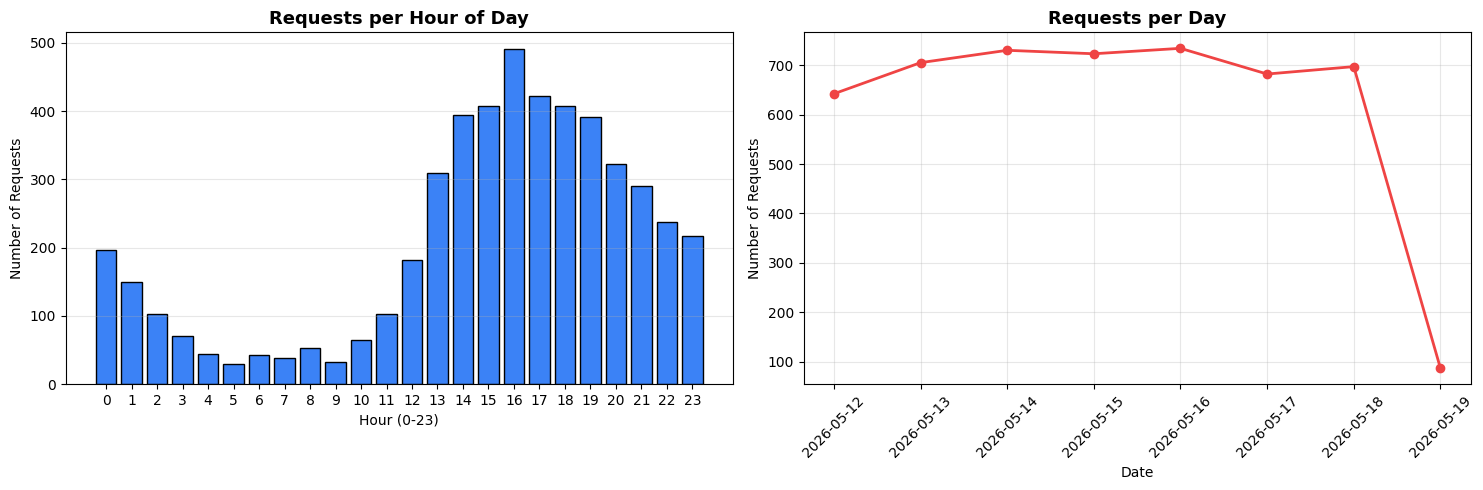

Chart saved: chart_traffic_timeseries.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(hourly["hour"], hourly["requests"], color="#3b82f6", edgecolor="black")
axes[0].set_title("Requests per Hour of Day", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Hour (0-23)")
axes[0].set_ylabel("Number of Requests")
axes[0].set_xticks(range(0, 24))
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(daily["day"], daily["requests"], marker="o", color="#ef4444", linewidth=2)
axes[1].set_title("Requests per Day", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Number of Requests")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("chart_traffic_timeseries.png", dpi=110, bbox_inches="tight")
plt.show()
print("Chart saved: chart_traffic_timeseries.png")

---
## 7. Novelty Feature #2 — Anomaly & Suspicious IP Detection

We flag an IP as **suspicious** if it exhibits attack-like behavior:
- More than **30% error rate** AND at least 10 total requests
- Attempts to access sensitive paths (`/wp-admin`, `/.env`, `/admin`, `/phpmyadmin`, etc.)

In [9]:
ip_stats = (
    logs.groupBy("ip")
    .agg(
        count("*").alias("total_requests"),
        _sum(when((col("status") >= 400) & (col("status") < 600), 1).otherwise(0)).alias("error_count"),
        _sum(when(col("status") == 404, 1).otherwise(0)).alias("notfound_count"),
        _sum(when(col("status") == 403, 1).otherwise(0)).alias("forbidden_count"),
    )
    .withColumn("error_rate_pct", (col("error_count") / col("total_requests") * 100))
)

suspicious_ips = (
    ip_stats.filter((col("error_rate_pct") > 30) & (col("total_requests") >= 10))
    .orderBy(desc("error_rate_pct"))
)
print("SUSPICIOUS IPs DETECTED (high error rate, possible attack):")
suspicious_ips.show(20, truncate=False)

SUSPICIOUS IPs DETECTED (high error rate, possible attack):
+--------------+--------------+-----------+--------------+---------------+-----------------+
|ip            |total_requests|error_count|notfound_count|forbidden_count|error_rate_pct   |
+--------------+--------------+-----------+--------------+---------------+-----------------+
|185.220.101.42|77            |77         |35            |24             |100.0            |
|194.165.16.77 |53            |53         |28            |11             |100.0            |
|45.155.205.99 |78            |78         |44            |20             |100.0            |
|192.168.47.14 |17            |7          |6             |0              |41.17647058823529|
|192.168.37.225|18            |6          |5             |0              |33.33333333333333|
+--------------+--------------+-----------+--------------+---------------+-----------------+



In [10]:
ATTACK_PATHS = ["/wp-admin", "/.env", "/config.php", "/wp-login.php",
                "/phpmyadmin", "/.git/config", "/admin"]
attack_filter = col("url").isin(ATTACK_PATHS) | col("url").startswith("/admin")

attackers = (
    logs.filter(attack_filter)
    .groupBy("ip")
    .agg(count("*").alias("attack_attempts"))
    .orderBy(desc("attack_attempts"))
)
print("IPs probing sensitive paths (likely scanners/attackers):")
attackers.show(20, truncate=False)

IPs probing sensitive paths (likely scanners/attackers):
+--------------+---------------+
|ip            |attack_attempts|
+--------------+---------------+
|45.155.205.99 |78             |
|185.220.101.42|77             |
|194.165.16.77 |53             |
|203.124.45.18 |33             |
|39.45.211.7   |32             |
|110.93.224.66 |29             |
|119.73.108.45 |28             |
|182.176.92.103|25             |
|192.168.47.30 |10             |
|192.168.44.190|9              |
|192.168.7.64  |8              |
|192.168.1.249 |8              |
|192.168.22.19 |8              |
|192.168.44.227|8              |
|192.168.17.207|7              |
|192.168.4.59  |7              |
|192.168.41.29 |7              |
|192.168.49.13 |7              |
|192.168.34.65 |7              |
|192.168.27.57 |7              |
+--------------+---------------+
only showing top 20 rows


---
## 8. Novelty Feature #3 — Bot vs Human Traffic Split

We classify traffic by analyzing the **User-Agent** string. Known bot signatures: `bot`, `crawler`, `spider`, `curl`, `wget`, `python-requests`, `Googlebot`, `bingbot`, etc.

Bot vs Human Traffic Split:
traffic_type  requests
         Bot      1210
       Human      3790


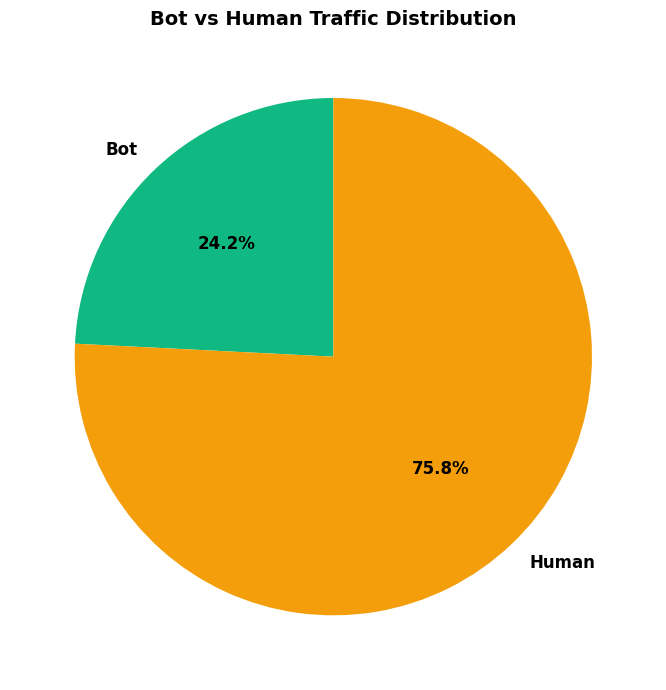

Chart saved: chart_bot_vs_human.png


In [11]:
bot_pattern = r"(?i)bot|crawler|spider|curl|wget|python-requests|facebookexternalhit|twitterbot"

classified = logs.withColumn(
    "traffic_type",
    when(col("user_agent").rlike(bot_pattern), "Bot").otherwise("Human")
)

split = (
    classified.groupBy("traffic_type")
    .agg(count("*").alias("requests"))
    .toPandas()
)
print("Bot vs Human Traffic Split:")
print(split.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 7))
colors = ["#10b981", "#f59e0b"]
ax.pie(split["requests"], labels=split["traffic_type"], autopct="%1.1f%%",
       startangle=90, colors=colors, textprops={"fontsize": 12, "fontweight": "bold"})
ax.set_title("Bot vs Human Traffic Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("chart_bot_vs_human.png", dpi=110, bbox_inches="tight")
plt.show()
print("Chart saved: chart_bot_vs_human.png")

In [12]:
print("Top 10 Bot User-Agents:")
(classified.filter(col("traffic_type") == "Bot")
    .groupBy("user_agent")
    .agg(count("*").alias("requests"))
    .orderBy(desc("requests"))
    .show(10, truncate=80))

Top 10 Bot User-Agents:
+---------------------------------------------------------------------------+--------+
|                                                                 user_agent|requests|
+---------------------------------------------------------------------------+--------+
|                                                                curl/7.88.1|     152|
|         Mozilla/5.0 (compatible; AhrefsBot/7.0; +http://ahrefs.com/robot/)|     132|
|                                                             Twitterbot/1.0|     125|
|   Mozilla/5.0 (compatible; Googlebot/2.1; +http://www.google.com/bot.html)|     123|
|Mozilla/5.0 (compatible; SemrushBot/7~bl; +http://www.semrush.com/bot.html)|     121|
|                                                     python-requests/2.31.0|     119|
|  facebookexternalhit/1.1 (+http://www.facebook.com/externalhit_uatext.php)|     116|
|           Mozilla/5.0 (compatible; YandexBot/3.0; +http://yandex.com/bots)|     113|
|    Mozilla/5.0 (c

## 9. Bonus Visualization — Status Code Distribution

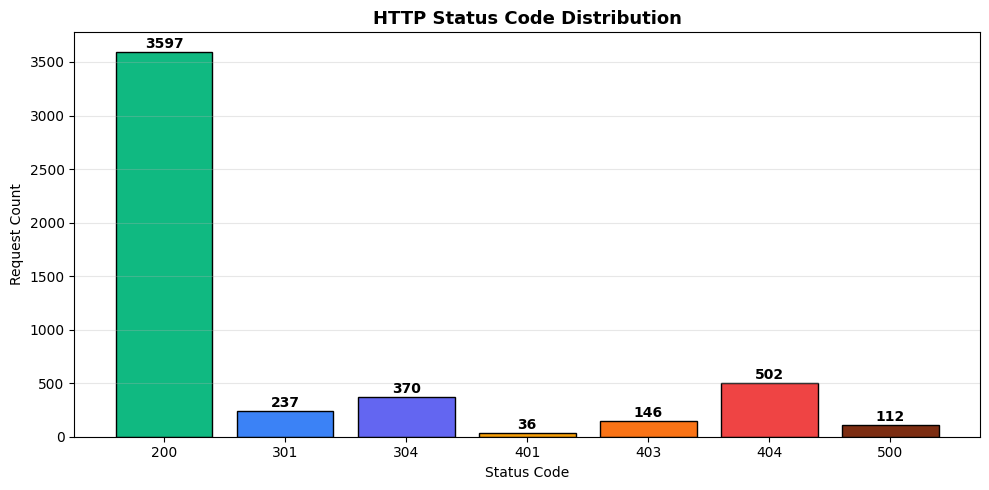

Chart saved: chart_status_codes.png


In [13]:
status_dist = (
    logs.groupBy("status").agg(count("*").alias("count"))
    .orderBy("status").toPandas()
)

fig, ax = plt.subplots(figsize=(10, 5))
colors_map = {200: "#10b981", 301: "#3b82f6", 304: "#6366f1",
              401: "#f59e0b", 403: "#f97316", 404: "#ef4444", 500: "#7c2d12"}
bar_colors = [colors_map.get(s, "#94a3b8") for s in status_dist["status"]]
ax.bar(status_dist["status"].astype(str), status_dist["count"],
       color=bar_colors, edgecolor="black")
ax.set_title("HTTP Status Code Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Status Code")
ax.set_ylabel("Request Count")
ax.grid(axis="y", alpha=0.3)
for i, v in enumerate(status_dist["count"]):
    ax.text(i, v + max(status_dist["count"]) * 0.01, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("chart_status_codes.png", dpi=110, bbox_inches="tight")
plt.show()
print("Chart saved: chart_status_codes.png")

In [14]:
spark.stop()
print("Spark session stopped. Project complete!")

Spark session stopped. Project complete!


---
## 10. Conclusion & Key Insights

### Business Insights
- **Capacity Planning**: Peak hours identify when server resources must be scaled up.
- **Security**: Suspicious IP detection + sensitive-path probing reveal active reconnaissance attempts that should be blocked at the WAF/firewall level.
- **SEO & Traffic Quality**: Bot vs human split tells us whether crawler traffic is dominating actual user engagement — important when interpreting analytics.
- **Reliability**: Error-rate trends per IP/per hour highlight outages or misconfigured endpoints.

### Why PySpark?
PySpark was chosen over plain Pandas because log files in production can reach **GBs to TBs per day**. The DataFrame API + Catalyst optimizer + lazy evaluation + distributed execution scale linearly — the same code runs on a laptop here and on a cluster in production.

---
**Stop Spark session:**